# SQL Agent with LangGraph — Walmart Sales
**Goal:** Build a SQL agent for the Walmart Sales database — from a LangChain SQL query chain to a LangGraph DAG that executes the SQL and returns Pandas DataFrames

## Libraries

In [1]:
from langchain_openai import ChatOpenAI
from langchain_community.utilities import SQLDatabase
from langchain_classic.chains import create_sql_query_chain

# LangGraph
from langgraph.graph import END, StateGraph
from typing import TypedDict

import pandas as pd
import sqlalchemy as sql
import os
import re
import yaml
from pprint import pprint

C:\Users\User\AppData\Local\Temp\ipykernel_14060\1179844273.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.utilities import SQLDatabase


## AI Setup

In [2]:
os.environ["OPENAI_API_KEY"] = yaml.safe_load(open('../credentials.yml'))['openai']

llm = ChatOpenAI(model="gpt-4o-mini")

## 1. SQL Database Setup

In [3]:
PATH_DB = "sqlite:///../data/walmart_sales.db"

sql_engine = sql.create_engine(PATH_DB)
conn = sql_engine.connect()

# Show all tables
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)

,name
0,daily_demand


In [4]:
db = SQLDatabase.from_uri(PATH_DB)

print("Dialect:", db.dialect)
print("Tables:", db.get_usable_table_names())
print("\nSample data:")
print(db.run("SELECT * FROM daily_demand LIMIT 5;"))

Dialect: sqlite
Tables: ['daily_demand']

Sample data:
[('FOODS_3_090', 1046, '2011-01-29'), ('FOODS_3_090', 1036, '2011-01-30'), ('FOODS_3_090', 673, '2011-01-31'), ('FOODS_3_090', 642, '2011-02-01'), ('FOODS_3_090', 531, '2011-02-02')]


## 2. SQL Parsing Utility

In [4]:
def extract_sql_code(text: str):
    """Extract the SQL query from an LLM response. Returns None if not found."""
    if not text:
        return None
    for pat in [
        r"SQLQuery:\s*```sql\s*([\s\S]+?)```",
        r"```sql\s*([\s\S]+?)```",
        r"```[\w]*\s*(SELECT[\s\S]+?)```",
        r"SQLQuery:\s*(SELECT[\s\S]+?)(?:\n\n|$)",
        r"(SELECT[\s\S]+?)(?:;|\n\n|$)",
    ]:
        m = re.search(pat, text, re.IGNORECASE)
        if m:
            return m.group(1).strip().rstrip(";")
    return None

## 3. SQL Agent + DataFrame Conversion

In [5]:
sql_generator = create_sql_query_chain(
    llm=llm,
    db=db,
    k=int(1e7),  # Set high to avoid LIMIT truncation
)

sql_generator

RunnableAssign(mapper={
  input: RunnableLambda(...),
  table_info: RunnableLambda(...)
})
| RunnableLambda(lambda x: {k: v for k, v in x.items() if k not in ('question', 'table_names_to_use')})
| PromptTemplate(input_variables=['input', 'table_info'], input_types={}, partial_variables={'top_k': '10000000'}, template='You are a SQLite expert. Given an input question, first create a syntactically correct SQLite query to run, then look at the results of the query and return the answer to the input question.\nUnless the user specifies in the question a specific number of examples to obtain, query for at most {top_k} results using the LIMIT clause as per SQLite. You can order the results to return the most informative data in the database.\nNever query for all columns from a table. You must query only the columns that are needed to answer the question. Wrap each column name in double quotes (") to denote them as delimited identifiers.\nPay attention to use only the column names you can see

In [6]:
# New: convert the SQL result to a Pandas DataFrame
response = sql_generator.invoke({"question": "Which 10 items have the highest total cumulative demand value?"})

df = pd.read_sql(extract_sql_code(response), conn)
df

,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333


In [7]:
# df.to_dict(orient="records") is JSON serializable — safe to store in graph state
df.to_dict(orient="records")

[{'item_id': 'FOODS_3_090', 'total_demand': 1002529},
 {'item_id': 'FOODS_3_586', 'total_demand': 920242},
 {'item_id': 'FOODS_3_252', 'total_demand': 565299},
 {'item_id': 'FOODS_3_555', 'total_demand': 491287},
 {'item_id': 'FOODS_3_714', 'total_demand': 396172},
 {'item_id': 'FOODS_3_587', 'total_demand': 396119},
 {'item_id': 'FOODS_3_694', 'total_demand': 390001},
 {'item_id': 'FOODS_3_226', 'total_demand': 363082},
 {'item_id': 'FOODS_3_202', 'total_demand': 295689},
 {'item_id': 'FOODS_3_723', 'total_demand': 284333}]

In [8]:
pd.DataFrame(df.to_dict(orient="records"))

,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333


## 4. Build a LangGraph DAG

In [6]:
class GraphState(TypedDict):
    """Represents the state of our graph."""
    question: str
    sql_query: str

In [7]:
def generate_sql(state):
    print("---GENERATE SQL---")
    question = state.get("question")
    sql_query = sql_generator.invoke({"question": question})
    sql_query = extract_sql_code(sql_query)
    return {"sql_query": sql_query}

In [8]:
def state_printer(state):
    """Print the state."""
    print("---STATE PRINTER---")
    print(f"question: {state.get('question')}")
    pprint(f"SQL Query:\n{state.get('sql_query')}")

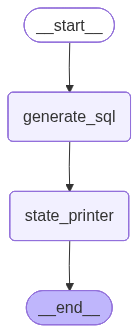

In [9]:
workflow = StateGraph(GraphState)

workflow.add_node("generate_sql", generate_sql)
workflow.add_node("state_printer", state_printer)

workflow.set_entry_point("generate_sql")
workflow.add_edge("generate_sql", "state_printer")
workflow.add_edge("state_printer", END)

app = workflow.compile()
app

In [10]:
QUESTION = "What are the top 10 items by total cumulative demand value?"

response = app.invoke({"question": QUESTION})
print("SQL:", response['sql_query'])
db.run(response['sql_query'])

---GENERATE SQL---


---STATE PRINTER---
question: What are the top 10 items by total cumulative demand value?
('SQL Query:\n'
 'SELECT "item_id", SUM("value") AS "total_demand"\n'
 'FROM "daily_demand"\n'
 'GROUP BY "item_id"\n'
 'ORDER BY "total_demand" DESC\n'
 'LIMIT 10')
SQL: SELECT "item_id", SUM("value") AS "total_demand"
FROM "daily_demand"
GROUP BY "item_id"
ORDER BY "total_demand" DESC
LIMIT 10


"[('FOODS_3_090', 1002529), ('FOODS_3_586', 920242), ('FOODS_3_252', 565299), ('FOODS_3_555', 491287), ('FOODS_3_714', 396172), ('FOODS_3_587', 396119), ('FOODS_3_694', 390001), ('FOODS_3_226', 363082), ('FOODS_3_202', 295689), ('FOODS_3_723', 284333)]"

## 5. Add a DataFrame Node to the Graph
Extend the graph state and add a node that executes the SQL and stores the result as a JSON-serializable DataFrame (records).

In [9]:
class GraphState(TypedDict):
    """Represents the state of our graph."""
    question: str
    sql_query: str
    # New: DataFrame stored as records
    data: dict

In [11]:
# New: execute the SQL and store the result as a DataFrame
def convert_dataframe(state):
    print("---CONVERT DATA FRAME---")
    sql_query = state.get("sql_query")
    df = pd.read_sql(sql_query, conn)
    return {"data": df.to_dict(orient="records")}

In [12]:
def state_printer(state):
    """Print the state."""
    print("---STATE PRINTER---")
    print(f"question: {state.get('question')}")
    pprint(f"SQL Query: {state.get('sql_query')}")
    print(f"Data: {pd.DataFrame(state.get('data')).to_string()}")

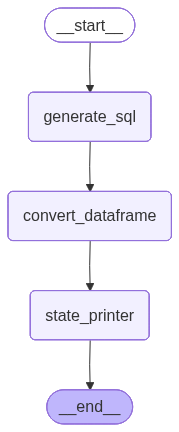

In [13]:
workflow = StateGraph(GraphState)

workflow.add_node("generate_sql", generate_sql)
workflow.add_node("convert_dataframe", convert_dataframe)
workflow.add_node("state_printer", state_printer)

workflow.set_entry_point("generate_sql")
workflow.add_edge("generate_sql", "convert_dataframe")
workflow.add_edge("convert_dataframe", "state_printer")
workflow.add_edge("state_printer", END)

app = workflow.compile()
app

## 6. Testing the Graph

In [14]:
QUESTION = "Which 10 items have the highest total cumulative demand value?"

response = app.invoke({"question": QUESTION})
pd.DataFrame(response.get("data"))

---GENERATE SQL---


---CONVERT DATA FRAME---
---STATE PRINTER---
question: Which 10 items have the highest total cumulative demand value?
('SQL Query: SELECT "item_id", SUM("value") AS total_demand \n'
 'FROM daily_demand \n'
 'GROUP BY "item_id" \n'
 'ORDER BY total_demand DESC \n'
 'LIMIT 10')
Data:        item_id  total_demand
0  FOODS_3_090       1002529
1  FOODS_3_586        920242
2  FOODS_3_252        565299
3  FOODS_3_555        491287
4  FOODS_3_714        396172
5  FOODS_3_587        396119
6  FOODS_3_694        390001
7  FOODS_3_226        363082
8  FOODS_3_202        295689
9  FOODS_3_723        284333


,item_id,total_demand
0,FOODS_3_090,1002529
1,FOODS_3_586,920242
2,FOODS_3_252,565299
3,FOODS_3_555,491287
4,FOODS_3_714,396172
5,FOODS_3_587,396119
6,FOODS_3_694,390001
7,FOODS_3_226,363082
8,FOODS_3_202,295689
9,FOODS_3_723,284333


In [15]:
QUESTION = "What are the names of each table in the database?"

response = app.invoke({"question": QUESTION})
pd.DataFrame(response.get("data"))

---GENERATE SQL---


---CONVERT DATA FRAME---
---STATE PRINTER---
question: What are the names of each table in the database?
"SQL Query: SELECT name FROM sqlite_master WHERE type='table'"
Data:            name
0  daily_demand


,name
0,daily_demand


In [16]:
QUESTION = "Extract the first 20 rows for item FOODS_3_090 from the daily_demand table, ordered by date."

response = app.invoke({"question": QUESTION})
pd.DataFrame(response.get("data"))

---GENERATE SQL---


---CONVERT DATA FRAME---
---STATE PRINTER---
question: Extract the first 20 rows for item FOODS_3_090 from the daily_demand table, ordered by date.
('SQL Query: SELECT "item_id", "value", "date" FROM daily_demand WHERE '
 '"item_id" = \'FOODS_3_090\' ORDER BY "date" LIMIT 20')
Data:         item_id  value        date
0   FOODS_3_090   1046  2011-01-29
1   FOODS_3_090   1036  2011-01-30
2   FOODS_3_090    673  2011-01-31
3   FOODS_3_090    642  2011-02-01
4   FOODS_3_090    531  2011-02-02
5   FOODS_3_090    877  2011-02-03
6   FOODS_3_090   1117  2011-02-04
7   FOODS_3_090   1311  2011-02-05
8   FOODS_3_090   1306  2011-02-06
9   FOODS_3_090    517  2011-02-07
10  FOODS_3_090      5  2011-02-08
11  FOODS_3_090      0  2011-02-09
12  FOODS_3_090      0  2011-02-10
13  FOODS_3_090      0  2011-02-11
14  FOODS_3_090      0  2011-02-12
15  FOODS_3_090      0  2011-02-13
16  FOODS_3_090      0  2011-02-14
17  FOODS_3_090      0  2011-02-15
18  FOODS_3_090      0  2011-02-16
19  FOODS_3_090 

,item_id,value,date
0,FOODS_3_090,1046,2011-01-29
1,FOODS_3_090,1036,2011-01-30
2,FOODS_3_090,673,2011-01-31
3,FOODS_3_090,642,2011-02-01
4,FOODS_3_090,531,2011-02-02
5,FOODS_3_090,877,2011-02-03
6,FOODS_3_090,1117,2011-02-04
7,FOODS_3_090,1311,2011-02-05
8,FOODS_3_090,1306,2011-02-06
9,FOODS_3_090,517,2011-02-07


In [17]:
QUESTION = "What is the total demand value by year-month? Order chronologically."

response = app.invoke({"question": QUESTION})
pd.DataFrame(response.get("data"))

---GENERATE SQL---


---CONVERT DATA FRAME---
---STATE PRINTER---
question: What is the total demand value by year-month? Order chronologically.
('SQL Query: SELECT strftime(\'%Y-%m\', "date") AS "year_month", SUM("value") '
 'AS "total_demand"\n'
 'FROM "daily_demand"\n'
 'GROUP BY "year_month"\n'
 'ORDER BY "year_month" ASC\n'
 'LIMIT 10000000')
Data:    year_month  total_demand
0     2011-01          9758
1     2011-02         69217
2     2011-03         64767
3     2011-04         69084
4     2011-05         69958
5     2011-06         73954
6     2011-07         81326
7     2011-08         84976
8     2011-09         77648
9     2011-10        108265
10    2011-11        104674
11    2011-12        111153
12    2012-01         91637
13    2012-02         92226
14    2012-03         98911
15    2012-04         94478
16    2012-05        105481
17    2012-06        108036
18    2012-07        111913
19    2012-08        119643
20    2012-09        106224
21    2012-10         97773
22    2012-11        

,year_month,total_demand
0,2011-01,9758
1,2011-02,69217
2,2011-03,64767
3,2011-04,69084
4,2011-05,69958
...,...,...
59,2015-12,70503
60,2016-01,80705
61,2016-02,88471
62,2016-03,89161


In [18]:
pprint(response.get("sql_query"))

('SELECT strftime(\'%Y-%m\', "date") AS "year_month", SUM("value") AS '
 '"total_demand"\n'
 'FROM "daily_demand"\n'
 'GROUP BY "year_month"\n'
 'ORDER BY "year_month" ASC\n'
 'LIMIT 10000000')


In [19]:
conn.close()